# Social Media Impact on Teen Mental Health
## An Exploratory Data Analysis

### Objective
To analyze how social media usage, sleep patterns, stress and anxiety levels 
relate to depression risk in teenagers aged 13-19.

### Dataset
- 1200 records, 13 features
- Source: Kaggle
- Target variable: depression_label (0 = No Depression, 1 = Depression)

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
tmh=pd.read_csv('dataset/project_dataset/Teen_Mental_Health_Dataset.csv')

In [6]:
tmh.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [7]:
tmh.shape

(1200, 13)

In [8]:
tmh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


In [9]:
tmh.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


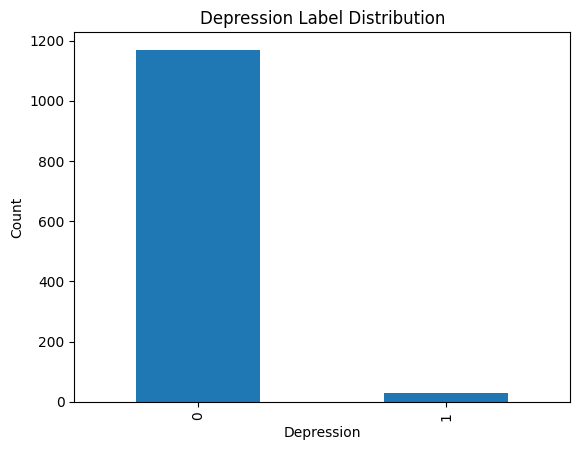

In [10]:

tmh['depression_label'].value_counts().plot(kind='bar')
plt.title('Depression Label Distribution')
plt.xlabel('Depression')
plt.ylabel('Count')
plt.show()

## 1. Depression Label Distribution
- Dataset is highly imbalanced - 1169 teens (97%) show no depression, 
  only 31 teens (3%) are labeled depressed.
- This class imbalance is an important finding and must be considered 
  in any future ML modeling on this dataset.

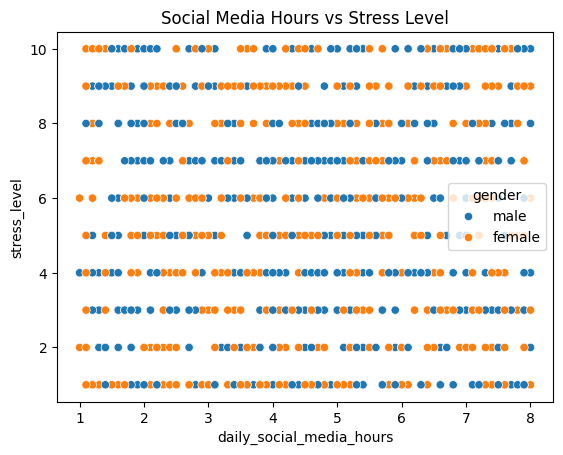

In [11]:
sns.scatterplot(x='daily_social_media_hours', y='stress_level', hue='gender', data=tmh)
plt.title('Social Media Hours vs Stress Level')
plt.show()

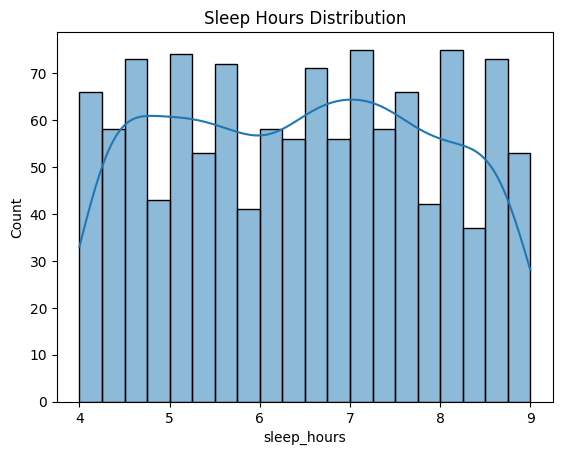

In [12]:
sns.histplot(tmh['sleep_hours'], bins=20, kde=True)
plt.title('Sleep Hours Distribution')
plt.show()

In [14]:
#tmh['depression_label'].value_counts()
tmh.corr(numeric_only=True)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
age,1.000000,-0.006635,0.001530,0.075612,-0.013973,0.011086,-0.031208,0.026363,0.038265,0.010973
daily_social_media_hours,-0.006635,1.000000,-0.009472,0.035777,0.013179,0.025546,0.030698,0.027835,-0.024964,0.175201
sleep_hours,0.001530,-0.009472,1.000000,0.010235,0.021866,0.012701,-0.010979,-0.011879,-0.054838,-0.190630
screen_time_before_sleep,0.075612,0.035777,0.010235,1.000000,-0.034715,-0.026450,-0.008650,-0.010344,0.028884,-0.016502
academic_performance,-0.013973,0.013179,0.021866,-0.034715,1.000000,0.023312,-0.000600,-0.064379,0.029354,0.001441
physical_activity,0.011086,0.025546,0.012701,-0.026450,0.023312,1.000000,0.012159,-0.022233,0.026200,-0.017598
stress_level,-0.031208,0.030698,-0.010979,-0.008650,-0.000600,0.012159,1.000000,0.015811,-0.000129,0.170474
anxiety_level,0.026363,0.027835,-0.011879,-0.010344,-0.064379,-0.022233,0.015811,1.000000,0.031154,0.169566
addiction_level,0.038265,-0.024964,-0.054838,0.028884,0.029354,0.026200,-0.000129,0.031154,1.000000,-0.013952
depression_label,0.010973,0.175201,-0.190630,-0.016502,0.001441,-0.017598,0.170474,0.169566,-0.013952,1.000000


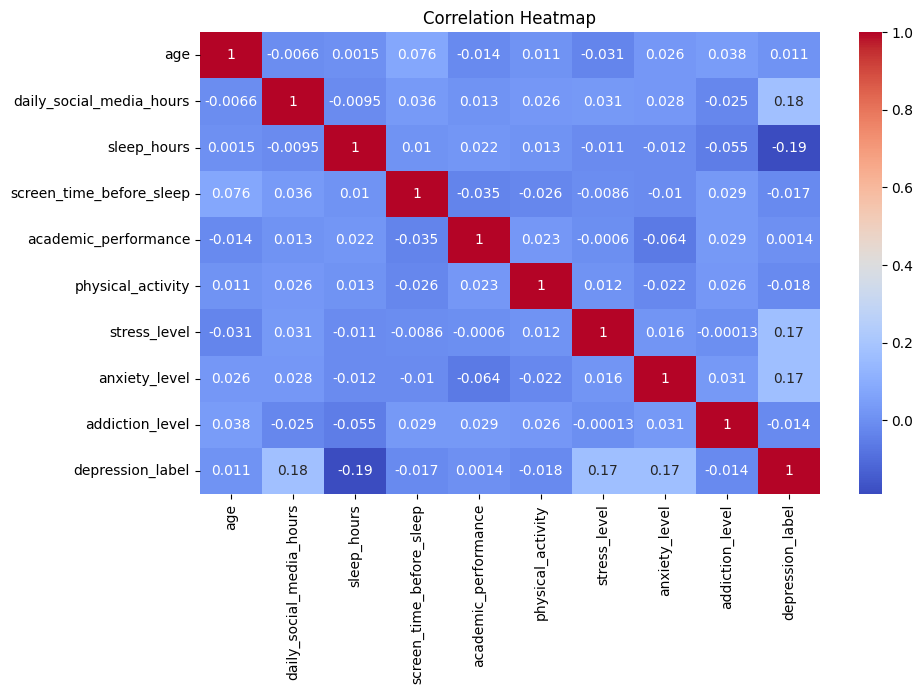

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(tmh.corr(numeric_only=True), annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 2. Correlation Analysis - Key Findings
- Sleep hours vs Depression: -0.19 (strongest relationship)
  Less sleep is associated with higher depression risk.
- Social media hours vs Depression: +0.18
  More social media usage is associated with higher depression risk.
- Stress level vs Depression: +0.17
  Higher stress correlates with depression.
- Anxiety level vs Depression: +0.17
  Higher anxiety correlates with depression.
- Age, academic performance, physical activity showed 
  no significant correlation with depression.

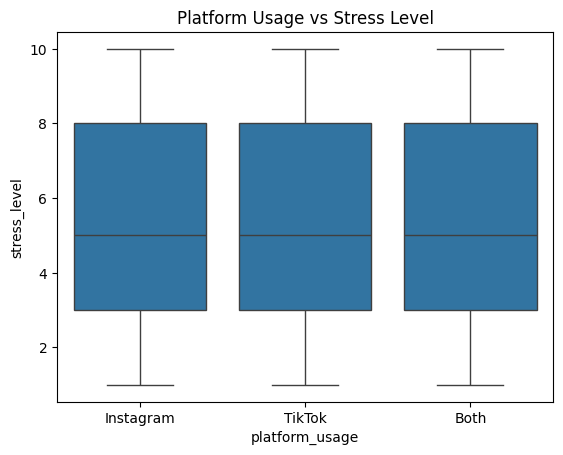

In [18]:
sns.boxplot(x='platform_usage', y='stress_level', data=tmh)
plt.title('Platform Usage vs Stress Level')
plt.show()

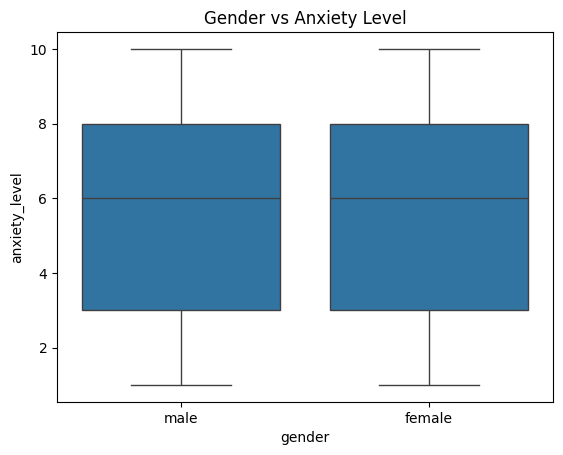

In [19]:
sns.boxplot(x='gender', y='anxiety_level', data=tmh)
plt.title('Gender vs Anxiety Level')
plt.show()

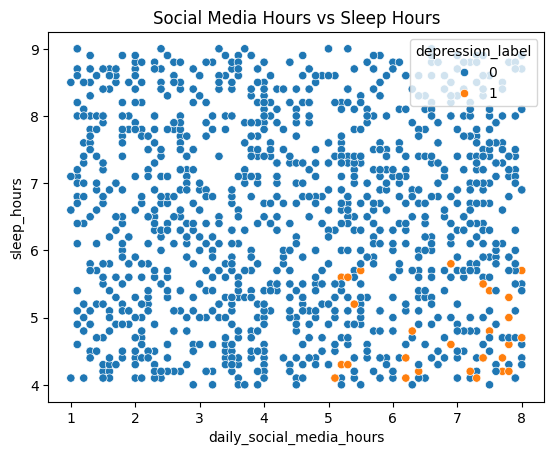

In [20]:
sns.scatterplot(x='daily_social_media_hours', y='sleep_hours', hue='depression_label', data=tmh)
plt.title('Social Media Hours vs Sleep Hours')
plt.show()

## 3. Key Visual Finding
- Teens with depression (label=1) clustered in a specific region:
  - Sleep hours: below 6 hours
  - Social media hours: 5 to 8 hours daily
- This visually confirms the correlation findings.
- High social media usage combined with low sleep 
  is the strongest pattern associated with depression risk.

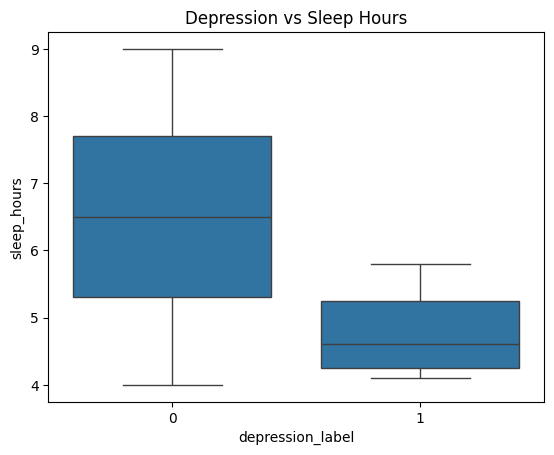

In [27]:
sns.boxplot(x='depression_label', y='sleep_hours', data=tmh)
plt.title('Depression vs Sleep Hours')
plt.show()

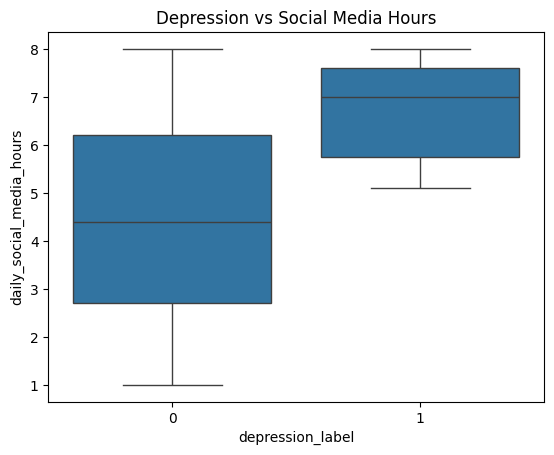

In [28]:
sns.boxplot(x='depression_label', y='daily_social_media_hours', data=tmh)
plt.title('Depression vs Social Media Hours')
plt.show()

## Conclusion

This analysis of 1200 teenagers reveals four key factors 
associated with depression risk:

1. SLEEP DEPRIVATION — Teens sleeping less than 6 hours 
   show higher depression risk. Strongest finding in this dataset.

2. HIGH SOCIAL MEDIA USAGE — Teens using social media 
   5-8 hours daily show higher depression risk.

3. STRESS AND ANXIETY — Both strongly correlate with depression.

4. PLATFORM DOESN'T MATTER — Instagram, TikTok, or Both 
   showed no significant difference in stress levels. 
   Usage amount matters more than platform choice.

5. GENDER SIMILARITY — No significant difference in anxiety 
   levels between male and female teenagers.

### Recommendation
Teenagers should limit social media usage to under 3 hours daily 
and maintain at least 7-8 hours of sleep to reduce depression risk.